| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 4** | **ADC, DAC, and Aliasing Signals** |
| **Name:** | Pascual, Ken Leonard |
| **Section:** | CPE41S2 |
| **Date Performed:** | 31 July 2026 |
| **Date Submitted:** | 31 July 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |


## 1. Objectives

This activity deals with the manipulation of audio signals using ADC and DAC techniques, including the inclusion of a programmatically developed aliasing filter.

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop an application program exhibiting the functions of DAC and ADC.

## 3. Discussion


In signal processing and related disciplines, aliasing is an effect that causes different signals to become indistinguishable (or aliases of one another) when sampled. It also often refers to the distortion or artifact that results when a signal reconstructed from samples is different from the original continuous signal.

Aliasing can occur in signals sampled in time, for instance digital audio, and is referred to as temporal aliasing. It can also occur in spatially sampled signals (e.g. moiré patterns in digital images); this type of aliasing is called spatial aliasing.

Aliasing is generally avoided by applying low-pass filters or anti-aliasing filters (AAF) to the input signal before sampling and when converting a signal from a higher to a lower sampling rate. Suitable reconstruction filtering should then be used when restoring the sampled signal to the continuous domain or converting a signal from a lower to a higher sampling rate. For spatial anti-aliasing, the types of anti-aliasing include fast sample anti-aliasing (FSAA), multisample anti-aliasing, and supersampling.


## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor
* Google Drive for csv files: https://drive.google.com/drive/folders/1X7DUlcP5pmDUYNMC9MwNF1N5YWAazjtD

## 5. Directions:

### 1. Develop a program to extract the wav file, snsd.wav, from the drive.



In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# Load snsd.wav
file_path = 'dataset/snsd.wav'
fs, data = wavfile.read(file_path)
print(f"File loaded: {file_path}")
print(f"Sampling Frequency: {fs} Hz")
print(f"Number of Samples: {len(data)}")
print(f"Duration: {len(data)/fs:.2f} seconds")
print(f"Channels: {data.shape[1] if len(data.shape) > 1 else 1}")
import os

# Output directory for exported audio files
os.makedirs('output', exist_ok=True)

def export_wav(filename, data, samplerate):
    """Export audio data as a WAV file to the output directory."""
    filepath = os.path.join('output', filename)
    wavfile.write(filepath, samplerate, data)
    print(f"Exported: {filepath}")

File loaded: dataset/snsd.wav
Sampling Frequency: 44100 Hz
Number of Samples: 8865792
Duration: 201.04 seconds
Channels: 2


### 2. Capture and plot the first 10 seconds of the audio signals and listen to it. As you plot the audio signal using a program, you are basically transforming the signal into digital signal. Notice the sampling frequency used to sample the audio signal, does it follow the sampling theorem?

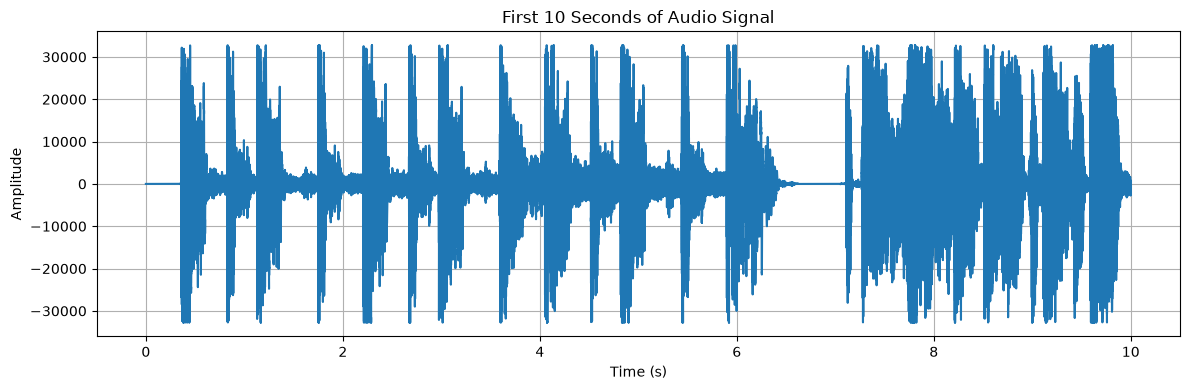


Sampling Frequency: 44100 Hz
Nyquist Frequency: 22050.0 Hz
Exported: output\step2_first10s.wav


In [42]:
# Plot first 10 seconds and analyze sampling theorem
# Convert audio to mono if it's in stereo
if len(data.shape) > 1:
    data_mono = np.mean(data, axis=1)
else:
    data_mono = data.astype(np.float64)

# Extract first 10 seconds
duration_sec = 10
num_samples_10s = int(duration_sec * fs)
signal_10s = data_mono[:num_samples_10s]
time_10s = np.arange(num_samples_10s) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_10s, signal_10s)
plt.title(f'First {duration_sec} Seconds of Audio Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Analysis of sampling theorem
nyquist_freq = fs / 2
print(f"\nSampling Frequency: {fs} Hz")
print(f"Nyquist Frequency: {nyquist_freq} Hz")


# Export first 10 seconds as WAV
signal_10s_int16 = np.int16(signal_10s / np.max(np.abs(signal_10s)) * 32767)
export_wav('step2_first10s.wav', signal_10s_int16, fs)


The sampling theorem (Nyquist-Shannon) requires fs > 2*fmax. Given that the sampling frequency (fs) is 44100 Hz, the maximum frequency that can be accurately represented based on the Nyquist-Shannon sampling theorem is half of the sampling frequency (fs), which is 22050 Hz. 

### 3. To mimic the analog filter, filter the captured signal with the use of low-pass Bessel filter using scipy.signal library and plot it. Provide the cutoff frequency.



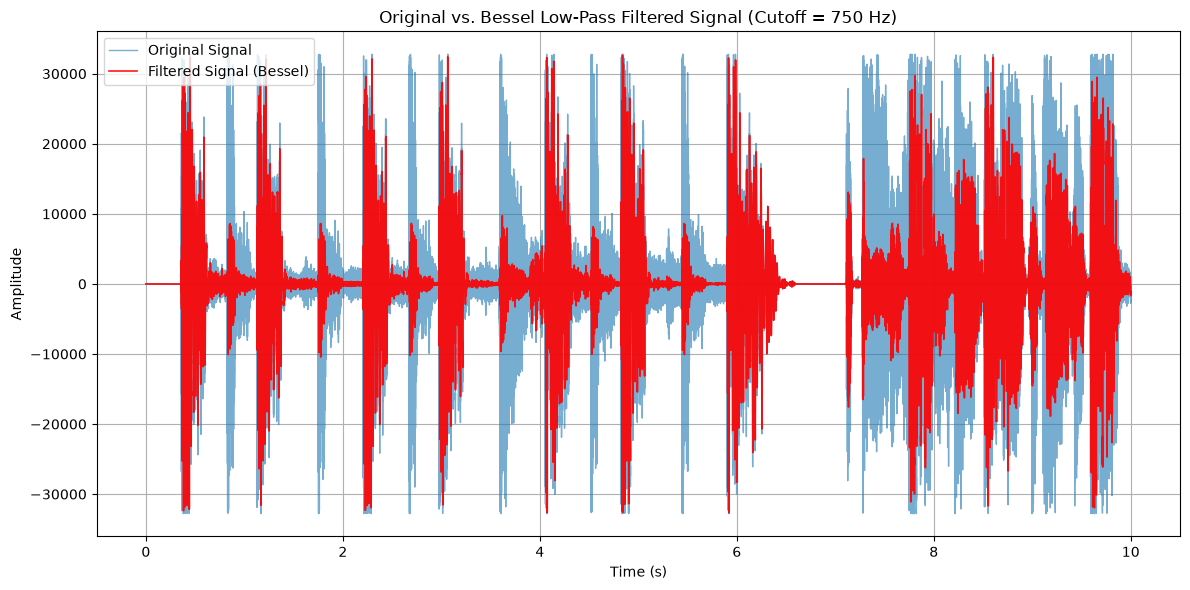

Bessel Filter Parameters:
  Cutoff Frequency: 750 Hz
  Filter Order: 5
  Normalized Cutoff (Wn): 0.0340
Exported: output\step3_bessel_filtered.wav


In [43]:
# Task 3: Apply low-pass Bessel filter to mimic analog filter
from scipy.signal import bessel, sosfilt

# Design Bessel filter
cutoff_freq = 750  # Cutoff frequency in Hz
filter_order = 5   # Filter order
Wn = cutoff_freq / (fs / 2)  # Normalized cutoff

# Create Bessel filter (low-pass)
sos = bessel(filter_order, Wn, btype='low', analog=False, output='sos')

# Apply the filter to the signal
filtered_signal = sosfilt(sos, signal_10s)

# Plot original and filtered signals overlaid
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time_10s, signal_10s, label='Original Signal', alpha=0.6, linewidth=1)
ax.plot(time_10s, filtered_signal, label='Filtered Signal (Bessel)', alpha=0.9, linewidth=1.2, color='red')
ax.set_title(f'Original vs. Bessel Low-Pass Filtered Signal (Cutoff = {cutoff_freq} Hz)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Bessel Filter Parameters:")
print(f"  Cutoff Frequency: {cutoff_freq} Hz")
print(f"  Filter Order: {filter_order}")
print(f"  Normalized Cutoff (Wn): {Wn:.4f}")

# Export Bessel filtered signal
filtered_int16 = np.int16(filtered_signal / np.max(np.abs(filtered_signal)) * 32767)
export_wav('step3_bessel_filtered.wav', filtered_int16, fs)


The cutoff frequency determines what frequency the filter starts affecting the sound. In this instance, the cutoff frequency is 750 Hz, meaning that only the sounds below 750 Hz won't be "filtered out" by the filter. However, since the filter used is a Bessel filter, it prioritizes preserving the shape of the waveform over time rather than achieving the sharpest possible frequency cutoff. This is why some parts would be seen not being cut off drastically, especially the high-frequency parts such as the drums. 

### 4. Using impulse train, perform 2 multirate techniques - one interpolation and the other decimation - and plot the 2 created sampled signals. Provide the number of samples for each technique. 



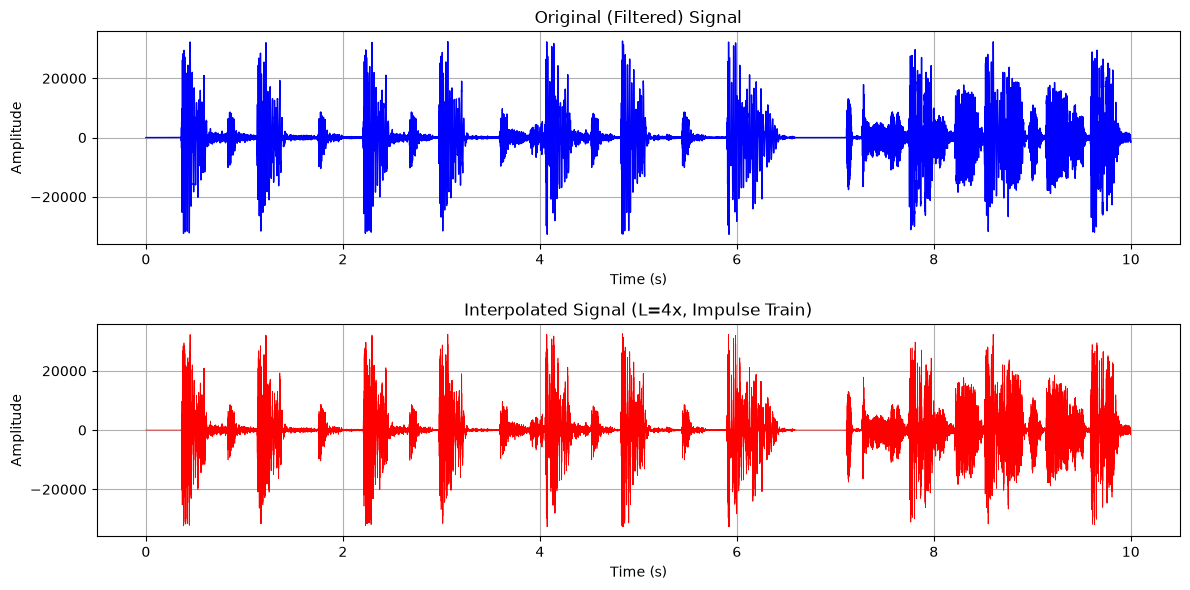

Original Signal:
  Number of samples: 441000
  Sampling rate: 44100 Hz

Interpolation (Upsampling):
  Factor L = 4
  Number of samples: 1764000
  New effective sampling rate: 176400 Hz
Exported: output\step4a_interpolated.wav


In [44]:
# Task 4: Multirate techniques using impulse train
# Interpolation (upsampling by factor L)
L = 4  # Interpolation factor
interpolated_samples = np.zeros(len(filtered_signal) * L)
interpolated_samples[::L] = filtered_signal  # Insert impulse train

# Decimation (downsampling by factor M)
M = 2  # Decimation factor
decimated_signal = filtered_signal[::M]  # Take every M-th sample

# Create time axes (all in real seconds, so they're directly comparable)
time_orig = time_10s
time_interp = np.arange(len(interpolated_samples)) / (fs * L)
time_decim = np.arange(len(decimated_signal)) / (fs / M)

# Plot 1: Original and Interpolated
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(time_orig, filtered_signal, 'b-', linewidth=1)
axes[0].set_title('Original (Filtered) Signal')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].plot(time_interp, interpolated_samples, 'r-', linewidth=0.5)
axes[1].set_title(f'Interpolated Signal (L={L}x, Impulse Train)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Original Signal:")
print(f"  Number of samples: {len(filtered_signal)}")
print(f"  Sampling rate: {fs} Hz")

print(f"\nInterpolation (Upsampling):")
print(f"  Factor L = {L}")
print(f"  Number of samples: {len(interpolated_samples)}")
print(f"  New effective sampling rate: {fs * L} Hz")

# Export interpolated signal
interp_int16 = np.int16(interpolated_samples / np.max(np.abs(interpolated_samples)) * 32767)
export_wav('step4a_interpolated.wav', interp_int16, fs * L)


Interpolation inserts extra samples between the existing ones so there are more data points per second. In the code, L=4 means we take the original signal and stretch it out by inserting 3 zero-valued samples between every original sample (that's the "impulse train", wherein there are zeros everywhere except at the original sample positions). 

In practice, the interpolated sample sounds harsh or buzzy if played back directly.
Visually, the waveforms look sharper when interpolated, since there are more samples per unit of time.

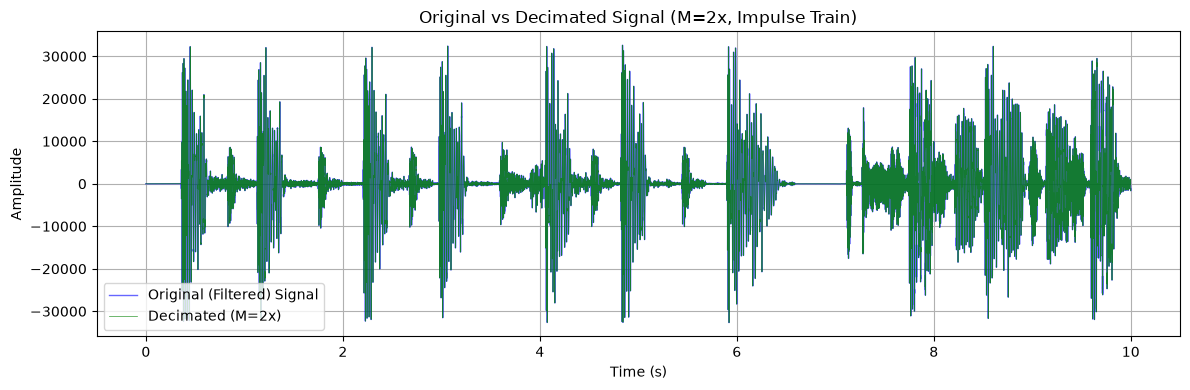

Original Signal:
  Number of samples: 441000
  Sampling rate: 44100 Hz

Decimation (Downsampling):
  Factor M = 2
  Number of samples: 220500
  New effective sampling rate: 22050.0 Hz
Exported: output\step4b_decimated.wav


In [45]:
# Plot 2: Original vs Decimated
plt.figure(figsize=(12, 4))
plt.plot(time_orig, filtered_signal, 'b-', linewidth=1, alpha=0.6, label='Original (Filtered) Signal')
plt.plot(time_decim, decimated_signal, 'g-', linewidth=0.5, alpha=0.8, label=f'Decimated (M={M}x)')
plt.title(f'Original vs Decimated Signal (M={M}x, Impulse Train)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Original Signal:")
print(f"  Number of samples: {len(filtered_signal)}")
print(f"  Sampling rate: {fs} Hz")

print(f"\nDecimation (Downsampling):")
print(f"  Factor M = {M}")
print(f"  Number of samples: {len(decimated_signal)}")
print(f"  New effective sampling rate: {fs / M} Hz")

# Export decimated signal
decim_int16 = np.int16(decimated_signal / np.max(np.abs(decimated_signal)) * 32767)
export_wav('step4b_decimated.wav', decim_int16, int(fs / M))


Contrary to interpolation, decimation reduces the numeber of samples being read per amount of time. This means that only every other sample gets kept, discarding the rest. 

In practice, this makes the audio sample sound like it was played at a lower audio quality, making it sound like how it was played in vintage players.

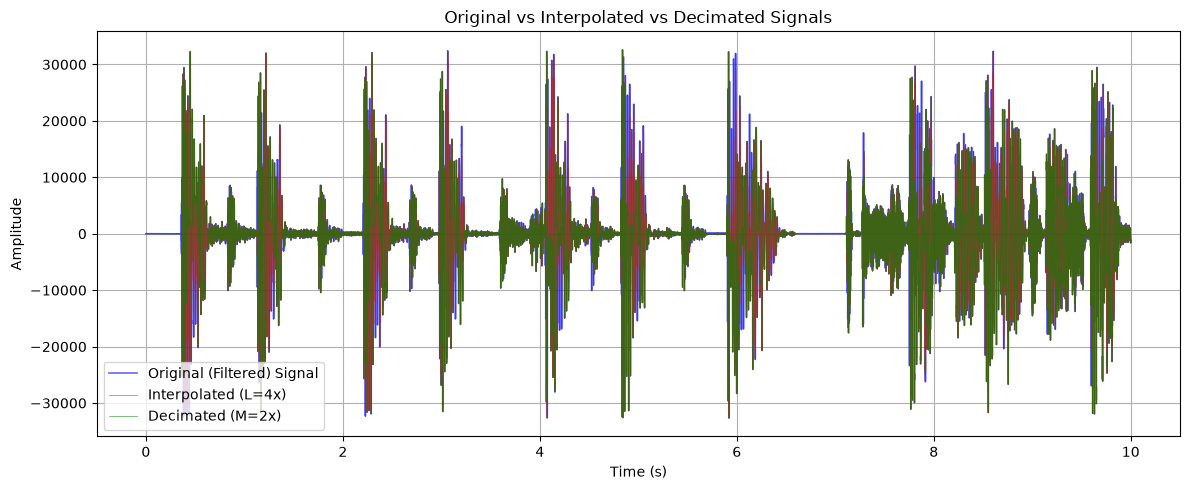

In [46]:
# Plot 3: All three overlaid together
plt.figure(figsize=(12, 5))
plt.plot(time_orig, filtered_signal, 'b-', linewidth=1.2, alpha=0.6, label='Original (Filtered) Signal')
plt.plot(time_interp, interpolated_samples, 'r-', linewidth=0.5, alpha=0.7, label=f'Interpolated (L={L}x)')
plt.plot(time_decim, decimated_signal, 'g-', linewidth=0.5, alpha=0.7, label=f'Decimated (M={M}x)')
plt.title('Original vs Interpolated vs Decimated Signals')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5. Then quantized both sampled signals for 8 bits. Plot the resulted digital signal.



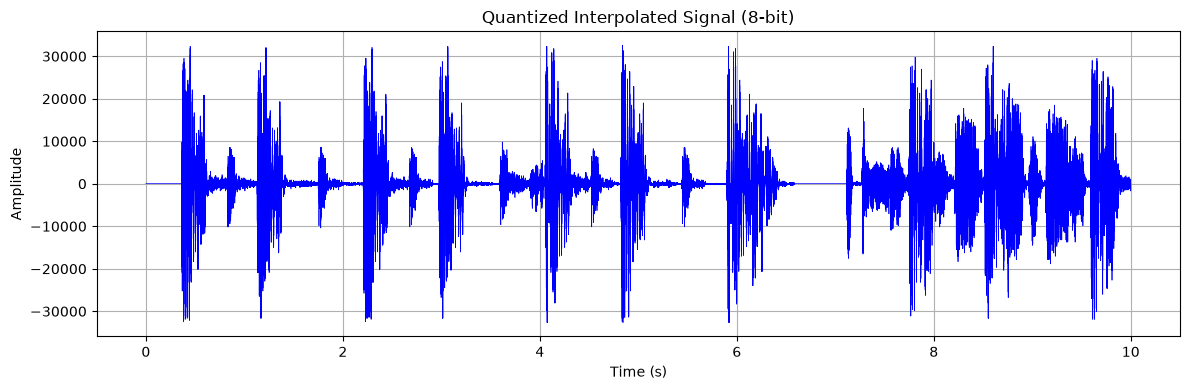

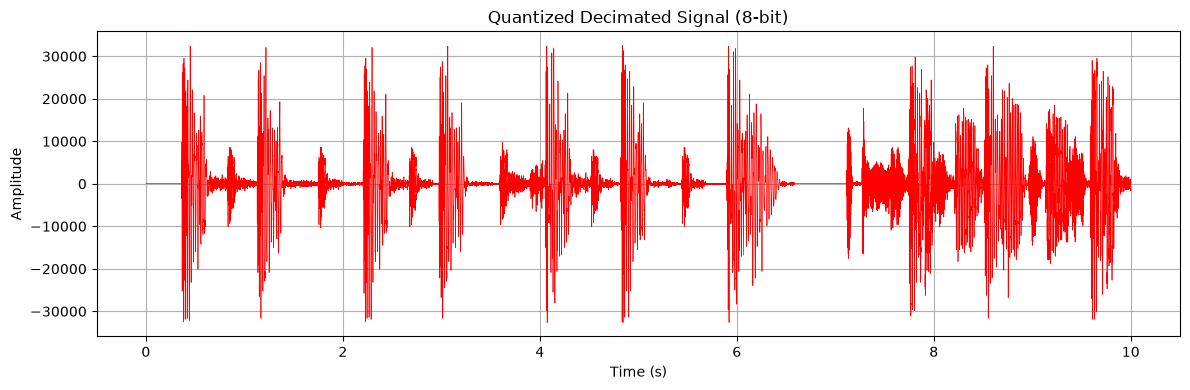

Quantization Parameters:
  Bit depth: 8 bits
  Number of quantization levels: 256
Exported: output\step5a_quantized_interpolated.wav
Exported: output\step5b_quantized_decimated.wav


In [47]:
# Quantize both sampled signals to 8 bits
n_bits = 8
n_levels = 2 ** n_bits  # 256 levels

def quantize(signal_data, n_bits):
    """Quantize signal to n_bits resolution"""
    min_val = np.min(signal_data)
    max_val = np.max(signal_data)
    
    if max_val == min_val:
        return np.zeros_like(signal_data, dtype=np.uint8)
    
    # Scale to [0, 1] range
    normalized = (signal_data - min_val) / (max_val - min_val)
    
    # Quantize to integer levels
    quantized = np.round(normalized * (n_levels - 1)).astype(np.uint8)
    
    # Scale back to original range
    dequantized = (quantized / (n_levels - 1)) * (max_val - min_val) + min_val
    
    return dequantized

# Quantize interpolated signal
quantized_interp = quantize(interpolated_samples, n_bits)

# Quantize decimated signal
quantized_decim = quantize(decimated_signal, n_bits)

# Plot quantized interpolated signal
plt.figure(figsize=(12, 4))
plt.plot(time_interp, quantized_interp, 'b-', linewidth=0.5)
plt.title(f'Quantized Interpolated Signal ({n_bits}-bit)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot quantized decimated signal
plt.figure(figsize=(12, 4))
plt.plot(time_decim, quantized_decim, 'r-', linewidth=0.5)
plt.title(f'Quantized Decimated Signal ({n_bits}-bit)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Quantization Parameters:")
print(f"  Bit depth: {n_bits} bits")
print(f"  Number of quantization levels: {n_levels}")

# Export quantized interpolated signal
quant_interp_int16 = np.int16(quantized_interp / np.max(np.abs(quantized_interp)) * 32767)
export_wav('step5a_quantized_interpolated.wav', quant_interp_int16, fs * L)

# Export quantized decimated signal
quant_decim_int16 = np.int16(quantized_decim / np.max(np.abs(quantized_decim)) * 32767)
export_wav('step5b_quantized_decimated.wav', quant_decim_int16, int(fs / M))


Quantization takes a signal's amplitude (which, in theory, can be any real number) and rounds it to one of a fixed number of discrete levels.

In this case, quantization squeezes the signal's amplitude range into 256 discrete steps (for 8 bits), rounding every value to the nearest step.

### 6. From digital signal, reconstruct the 2 signals using a zeroth-order method (you may use available python module/function). Plot the resulted signals.



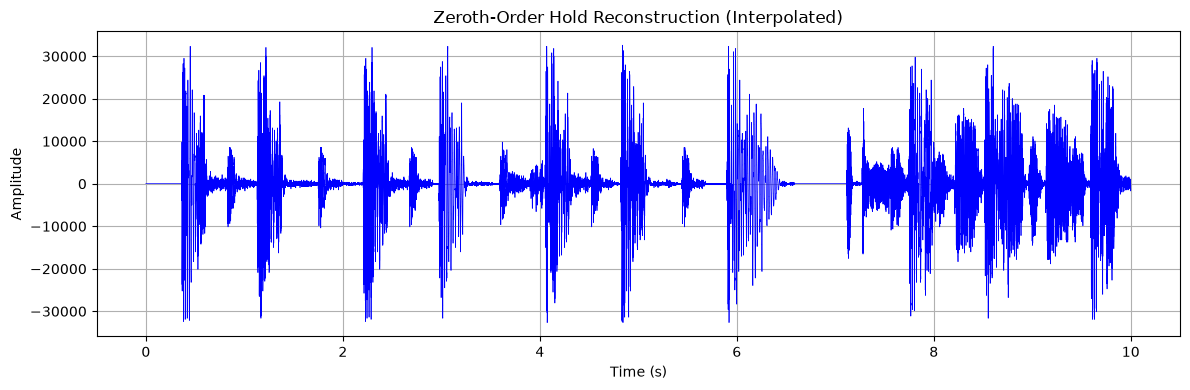

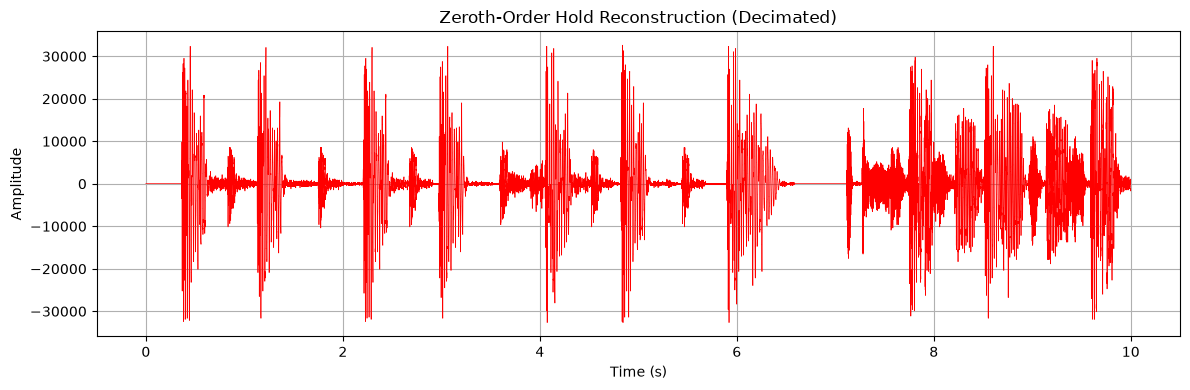

Zeroth-Order Hold (ZOH) Reconstruction completed.
Interpolated reconstructed samples: 441000
Decimated reconstructed samples: 441000
Exported: output\step6a_zoh_reconstructed_interpolated.wav
Exported: output\step6b_zoh_reconstructed_decimated.wav


In [48]:
# Reconstruct signals using zeroth-order hold method
from scipy.interpolate import interp1d

def zeroth_order_hold(samples, original_fs, target_fs):
    """Reconstruct signal using zeroth-order hold (ZOH)"""
    n_samples = len(samples)
    duration = n_samples / target_fs
    
    # Create time arrays
    t_original = np.arange(n_samples) / target_fs
    t_reconstructed = np.arange(int(duration * original_fs)) / original_fs
    
    # Zeroth-order hold: create a step function
    reconstructed = np.zeros(len(t_reconstructed))
    for i, t in enumerate(t_reconstructed):
        idx = int(t * target_fs)
        if idx < n_samples:
            reconstructed[i] = samples[idx]
    
    return t_reconstructed, reconstructed

# Reconstruct interpolated signal
time_zoh_interp, reconstructed_interp = zeroth_order_hold(
    quantized_interp, fs, fs * L
)

# Reconstruct decimated signal
time_zoh_decim, reconstructed_decim = zeroth_order_hold(
    quantized_decim, fs, fs // M
)

# Plot reconstructed interpolated signal
plt.figure(figsize=(12, 4))
plt.plot(time_zoh_interp, reconstructed_interp, 'b-', linewidth=0.5)
plt.title('Zeroth-Order Hold Reconstruction (Interpolated)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot reconstructed decimated signal
plt.figure(figsize=(12, 4))
plt.plot(time_zoh_decim, reconstructed_decim, 'r-', linewidth=0.5)
plt.title('Zeroth-Order Hold Reconstruction (Decimated)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Zeroth-Order Hold (ZOH) Reconstruction completed.")
print(f"Interpolated reconstructed samples: {len(reconstructed_interp)}")
print(f"Decimated reconstructed samples: {len(reconstructed_decim)}")

# Export ZOH reconstructed interpolated signal
recon_interp_int16 = np.int16(reconstructed_interp / np.max(np.abs(reconstructed_interp)) * 32767)
export_wav('step6a_zoh_reconstructed_interpolated.wav', recon_interp_int16, fs)

# Export ZOH reconstructed decimated signal
recon_decim_int16 = np.int16(reconstructed_decim / np.max(np.abs(reconstructed_decim)) * 32767)
export_wav('step6b_zoh_reconstructed_decimated.wav', recon_decim_int16, fs)


From quantization, the signals are then reconstructed into a continuous-looking signal by holding each sample's value flat until the next one arrives. This creates a staircase-like waveform, as illustrated below. Once zoomed out, this staircase-like waveform is not much noticeable, as illustrated above.

This process converts the quantized signals from discrete samples back into a step-function approximation of a continuous signal.

The zeroth-order hold (ZOH) method was used, as it was the simplest way to reconstruct a continuous signal from discrete samples. Basically, it takes each sample's value and holds it constant until the next sample comes along, creating a staircase-like shape instead of a smooth curve. The order refers to the degree of the polynomial used to connect the points in the sample. Using higher-order methods can produce smoother transitions between each sample.

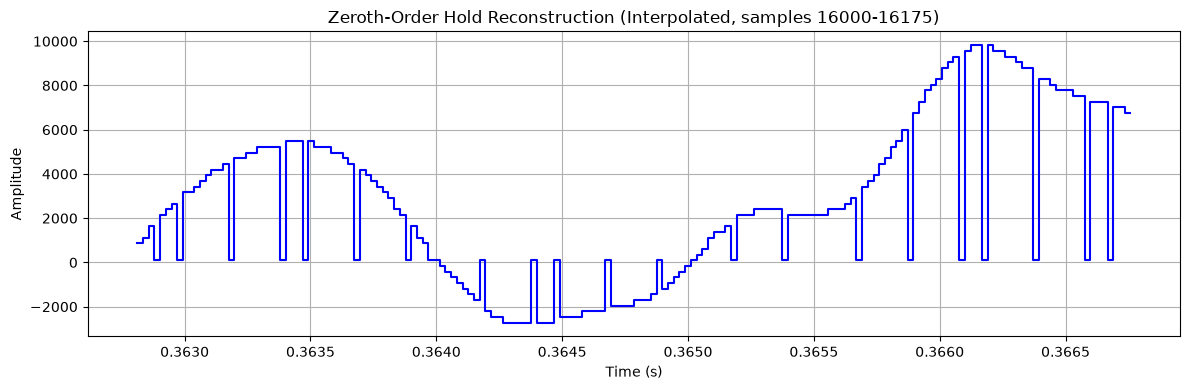

In [49]:
start_sample = 16000   # adjust to skip past the blank region
zoom_samples = 175     # small enough to actually see the ZOH steps

plt.figure(figsize=(12, 4))
plt.step(
    time_zoh_interp[start_sample:start_sample+zoom_samples],
    reconstructed_interp[start_sample:start_sample+zoom_samples],
    where='post', color='b'
)
plt.title(f'Zeroth-Order Hold Reconstruction (Interpolated, samples {start_sample}-{start_sample+zoom_samples})')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

### 7. Smooth the 2 signals using reconstruction filter (Bessel filter). Plot it and listen to it.



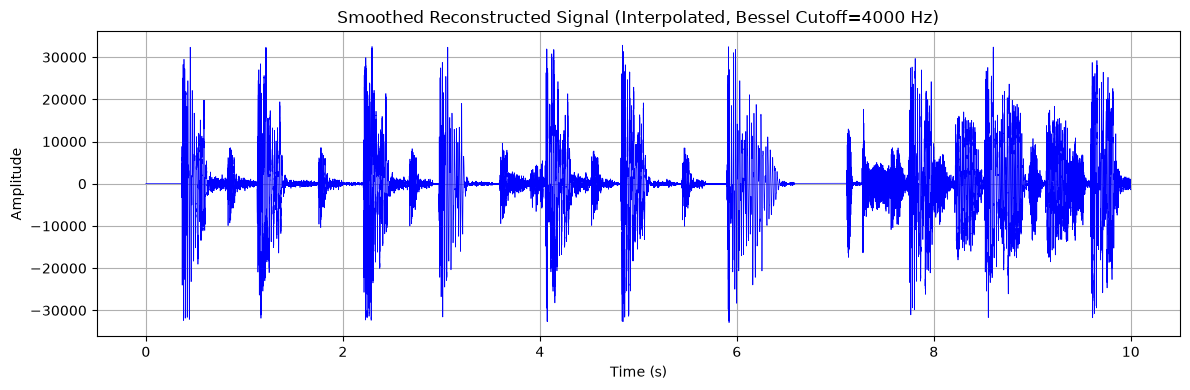

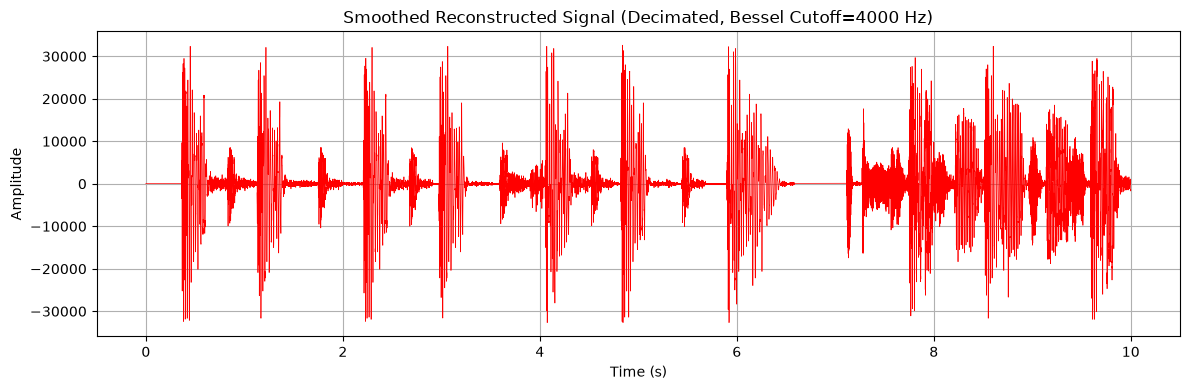

Bessel Reconstruction Filter Parameters:
  Cutoff Frequency: 4000 Hz
  Filter Order: 4
  Normalized Cutoff (Wn): 0.1814
Exported: output\step7a_smoothed_interpolated.wav
Exported: output\step7b_smoothed_decimated.wav


In [50]:
# Task 7: Smooth signals using Bessel reconstruction filter
# Design reconstruction Bessel filter
recon_cutoff = 4000  # Reconstruction filter cutoff
recon_order = 4
Wn_recon = recon_cutoff / (fs / 2)

# Create reconstruction filter
sos_recon = bessel(recon_order, Wn_recon, btype='low', analog=False, output='sos')

# Apply reconstruction filter to interpolated signal
smoothed_interp = sosfilt(sos_recon, reconstructed_interp)

# Apply reconstruction filter to decimated signal
smoothed_decim = sosfilt(sos_recon, reconstructed_decim)

# Plot smoothed interpolated signal
plt.figure(figsize=(12, 4))
plt.plot(time_zoh_interp, smoothed_interp, 'b-', linewidth=0.5)
plt.title(f'Smoothed Reconstructed Signal (Interpolated, Bessel Cutoff={recon_cutoff} Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot smoothed decimated signal
plt.figure(figsize=(12, 4))
plt.plot(time_zoh_decim, smoothed_decim, 'r-', linewidth=0.5)
plt.title(f'Smoothed Reconstructed Signal (Decimated, Bessel Cutoff={recon_cutoff} Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Bessel Reconstruction Filter Parameters:")
print(f"  Cutoff Frequency: {recon_cutoff} Hz")
print(f"  Filter Order: {recon_order}")
print(f"  Normalized Cutoff (Wn): {Wn_recon:.4f}")

# Export Bessel-smoothed interpolated signal
smooth_interp_int16 = np.int16(smoothed_interp / np.max(np.abs(smoothed_interp)) * 32767)
export_wav('step7a_smoothed_interpolated.wav', smooth_interp_int16, fs)

# Export Bessel-smoothed decimated signal
smooth_decim_int16 = np.int16(smoothed_decim / np.max(np.abs(smoothed_decim)) * 32767)
export_wav('step7b_smoothed_decimated.wav', smooth_decim_int16, fs)


In this filter, the cutoff frequency indicates that frequencies higher than that would be subject for smoothing. The filter order controls how aggressively the filter transitions around the cutoff frequency (higher means steeper transition). Normalized cutoff is the same as the cutoff frequency, but rescaled into the format scipy.signal.bessel() expects, which is a fraction between 0 and 1, where 1 represents the Nyquist frequency (fs/2).

Since the reconstruction process using the ZOH method produced a staircase-like signal, a filter was used to smooth the sharp transitions from that process. This results into a more analog-like curve from the reconstruction, as seen below. Basically, this is like the anti-aliasing process to turn the digital signal into something similar or identical to an analog signal.

The resulting waveform at the end sounds a bit identical to the sound of the original waveform after being fed through the Bessel low-pass filter.

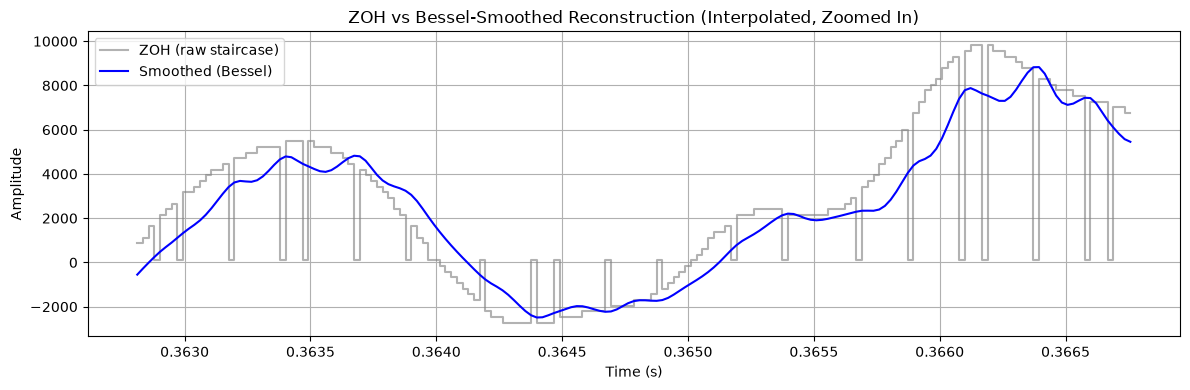

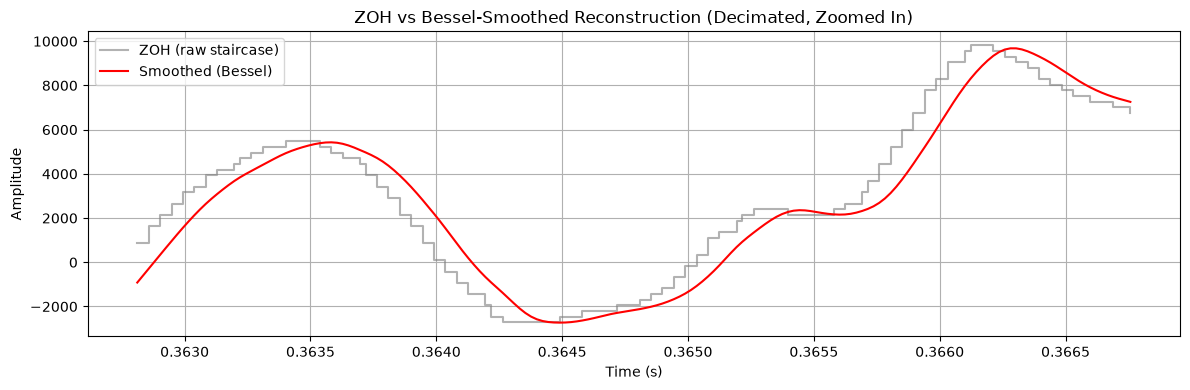

In [51]:
# Zoom in to compare raw ZOH staircase vs Bessel-smoothed signal
start_sample = 16000
zoom_samples = 175

# --- Interpolated: ZOH vs Smoothed ---
plt.figure(figsize=(12, 4))
plt.step(time_zoh_interp[start_sample:start_sample+zoom_samples],
         reconstructed_interp[start_sample:start_sample+zoom_samples],
         where='post', color='gray', alpha=0.6, label='ZOH (raw staircase)')
plt.plot(time_zoh_interp[start_sample:start_sample+zoom_samples],
         smoothed_interp[start_sample:start_sample+zoom_samples],
         'b-', linewidth=1.5, label='Smoothed (Bessel)')
plt.title('ZOH vs Bessel-Smoothed Reconstruction (Interpolated, Zoomed In)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Decimated: ZOH vs Smoothed ---
plt.figure(figsize=(12, 4))
plt.step(time_zoh_decim[start_sample:start_sample+zoom_samples],
         reconstructed_decim[start_sample:start_sample+zoom_samples],
         where='post', color='gray', alpha=0.6, label='ZOH (raw staircase)')
plt.plot(time_zoh_decim[start_sample:start_sample+zoom_samples],
         smoothed_decim[start_sample:start_sample+zoom_samples],
         'r-', linewidth=1.5, label='Smoothed (Bessel)')
plt.title('ZOH vs Bessel-Smoothed Reconstruction (Decimated, Zoomed In)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 8. Provide an analysis for each result

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

In this activity, I was able to develop an application program exhibiting the functions of DAC and ADC. The complete ADC/DAC pipeline was demonstrated, starting from the original analog signal, then the  anti-aliasing filter, sampling (interpolation/decimation), quantization, reconstruction (ZOH) and finally, the using the smoothing filter.

The anti-aliasing filter removes frequencies above the set threshold before sampling, to prevent aliasing

Then, the sampling process (interpolation/decimation) changes the sample rate, simulating rate conversion.

Quantization then rounds each sample's amplitude to one of 256 discrete levels, converting the continuous amplitude into digial values at the cost of small quantization noise.

Then, reconstruction through a zeroth-order hold method was done to start bringing back the digital signal back into an analog-like signal

Finally, a smoothing filter is applied to the reconstructed signal to smoothen the reconstructed signal, completing pipeline.

The resulting waveform at the end sounds a bit identical to the sound of the original waveform after being fed through the Bessel low-pass filter.

## 8. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.’s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.